# Demanda Eléctrica en Texas (ERCOT)

## Objetivo y tarea de pronóstico

Antes de explorar, declaramos **qué vamos a predecir**, porque eso define qué estructura
de los datos importa, qué modelo gana y cómo se evalúa:

- **Variable objetivo:** demanda eléctrica horaria de Texas (`cleaned demand (MW)`).
- **Tarea:** pronóstico **multi-paso a 24 horas** (las próximas 24 horas a partir de la
  última observación disponible). Es el horizonte operativamente relevante para ERCOT
  (programación de generación del día siguiente) y el que mejor expone los ciclos
  diario y semanal que veremos en el EDA.
- **Modelos a comparar:** **ARIMA/SARIMA** (modelo estadístico clásico, exige
  estacionariedad) frente a **LSTM** (red recurrente, captura no linealidades y
  dependencias largas sin supuesto de estacionariedad).
- **Métrica:** MAE y RMSE sobre el horizonte de 24 h, más MAPE para lectura relativa.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


df = pd.read_csv('Data/TEX.csv', parse_dates=['date_time'], na_values=['MISSING', 'EMPTY'])
df = df.set_index('date_time')

df.shape

print(f"Max date: {df.index.max()}")
print(f"Min date: {df.index.min()}")

print(df['cleaned demand (MW)'].describe())
print(df['cleaned demand (MW)'].isna().sum())

Max date: 2024-12-31 23:00:00
Min date: 2020-01-01 00:00:00
count    43848.000000
mean     48247.804643
std      10947.427884
min      27445.000000
25%      40373.750000
50%      45663.500000
75%      53990.250000
max      85559.000000
Name: cleaned demand (MW), dtype: float64
0


## Zona horaria: los timestamps están en **UTC**, no en hora local de Texas

Esto es un problema al analizar todo esto que es importante tocar si es que se manejan temperaturas (por el momento no se tiene planteado eso).
Esto es crítico y fácil de pasar por alto. La demanda horaria de la EIA (fuente de ERCOT)
se publica con marca de tiempo en **UTC**. Si leemos el eje horario de forma literal,
el pico de verano cae cerca de las 22–23 h y el valle cerca de las 10 h, lo cual sería
absurdo en hora local (nadie tiene su máximo de aire acondicionado a las 10 de la noche
ni su mínimo a las 10 de la mañana).

Convertido a **America/Chicago** (hora local de Texas, con horario de verano):
- pico ≈ **17 h (5 PM)** → máximo real de aire acondicionado por la tarde,
- valle ≈ **5 h (5 AM)** → mínimo real de madrugada.

**Para el proyecto:** cuando incorporemos temperatura u
otras covariables climáticas, éstas suelen venir en **hora local**. Mezclar demanda en
UTC con clima en hora local introduce un desfase de **5–6 horas** (oscila porque Texas
cambia a horario de verano) que **destruye la correlación** y nos haría
creer que la temperatura "no sirve". **Decisión:** fijar una sola zona horaria para
todo el pipeline y convertir explícitamente antes de cualquier `merge` temporal.


In [46]:
print(df.index.to_series().diff().value_counts()) 

date_time
0 days 01:00:00    43847
Name: count, dtype: int64


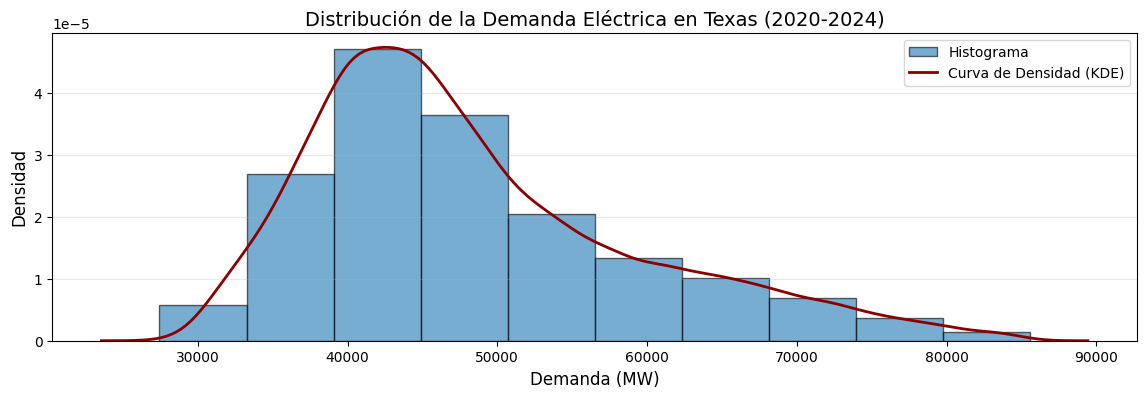

In [47]:
plt.figure(figsize=(14,4))

plt.hist(df['cleaned demand (MW)'], color='#1f77b4', edgecolor='black', density=True, alpha=0.6, label='Histograma')

sns.kdeplot(df['cleaned demand (MW)'], color='darkred', linewidth=2, label='Curva de Densidad (KDE)')

plt.title('Distribución de la Demanda Eléctrica en Texas (2020-2024)', fontsize=14)
plt.xlabel('Demanda (MW)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
from scipy import stats

d = df['cleaned demand (MW)']

print('Estadisticos de forma y dispersión')
print(d.describe().round(1))
print()
print(f'Asimetría (skew):          {stats.skew(d.dropna()):.3f}')
print(f'Curtosis (exceso):         {stats.kurtosis(d.dropna()):.3f}')
print(f'Coef. de variación:        {d.std()/d.mean():.3f}')

# Razón pico/valle del perfil horario promedio
perfil = d.groupby(d.index.hour).mean()
print(f'Razón pico/valle (perfil horario): {perfil.max()/perfil.min():.3f}')


--- Estadísticos de forma y dispersión ---
count    43848.0
mean     48247.8
std      10947.4
min      27445.0
25%      40373.8
50%      45663.5
75%      53990.2
max      85559.0
Name: cleaned demand (MW), dtype: float64

Asimetría (skew):          0.922
Curtosis (exceso):         0.386
Coef. de variación:        0.227
Razón pico/valle (perfil horario): 1.371


## Análisis de la distribución

La densidad (KDE) muestra una distribución **unimodal** con moda alrededor de
**~40,000 MW** y **sesgo a la derecha**. La cola larga la aportan los **picos de verano**
de forma sistemática; el invierno contribuye poco a esa cola de manera estructural y
aparece más como **golpes ocasionales de frío** (uno de ellos, Uri).

Cuantificado:

| Estadístico | Valor |
|---|---|
| Media | 48,248 MW |
| Mediana | 45,664 MW |
| Desv. estándar | 10,947 MW |
| **Asimetría (skew)** | **0.92** (sesgo derecho claro) |
| **Curtosis (exceso)** | **0.39** (colas algo más pesadas que la normal) |
| Mínimo | 27,445 MW |
| Máximo | 85,559 MW |

La asimetría positiva (0.92) confirma que la media (48,248) supera a la mediana (45,664):
hay horas de demanda muy alta poco frecuentes pero significativas.

**Decisiones de modelado derivadas:**
- **ARIMA:** el sesgo a la derecha sugiere evaluar una **transformación log o Box-Cox**
  para estabilizar la varianza antes de ajustar.
- **LSTM:** aplicar **escalado** (MinMax o estandarización) ajustado **solo con el
  conjunto de entrenamiento** para no filtrar información del test.


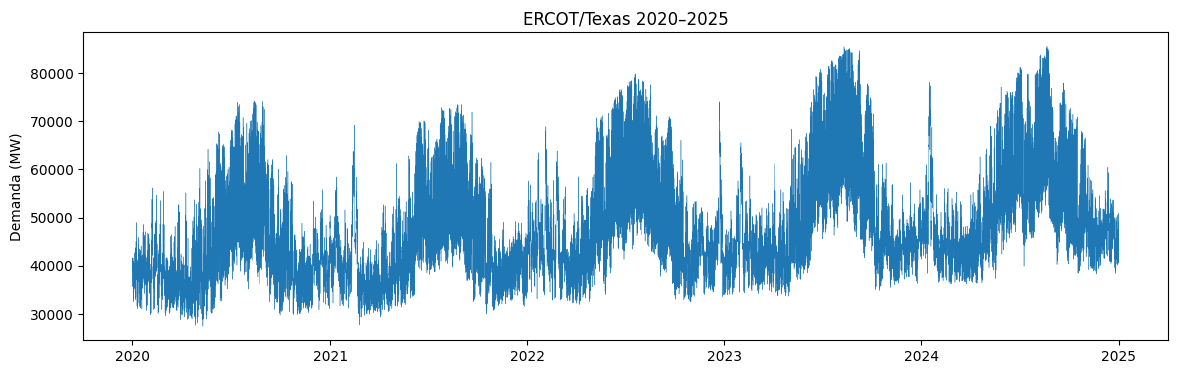

In [49]:
plt.figure(figsize=(14,4))
plt.plot(df.index, df['cleaned demand (MW)'], linewidth=0.3)
plt.ylabel('Demanda (MW)'); plt.title('ERCOT/Texas 2020–2025')
plt.show()

## Eventos atípicos y calidad del dato

La serie completa contiene tres situaciones que **no representan demanda normal** y que
hay que **medir** y **convertir en una decisión** antes de modelar:
la tormenta **Uri** (feb-2021), el **confinamiento por COVID** (2020) y las **horas
imputadas** que trae la columna limpia.


In [ ]:
# El confinamiento por COVID movió la demanda de forma significativa?
# Comparamos la misma ventana estacional (15-mar a 30-abr) de 2020 vs 2021.
covid_2020 = d['2020-03-15':'2020-04-30'].mean()
base_2021  = d['2021-03-15':'2021-04-30'].mean()
delta = (covid_2020 - base_2021) / base_2021 * 100

print(f'Demanda media 15-mar a 30-abr 2020 (confinamiento): {covid_2020:,.0f} MW')
print(f'Demanda media 15-mar a 30-abr 2021 (referencia):    {base_2021:,.0f} MW')
print(f'Diferencia: {delta:+.2f} %  esto pues dentro del ruido, NO es un efecto significativo')


Demanda media 15-mar a 30-abr 2020 (confinamiento): 37,788 MW
Demanda media 15-mar a 30-abr 2021 (referencia):    38,211 MW
Diferencia: -1.11 %  esto pues dentro del ruido, NO es un efecto significativo


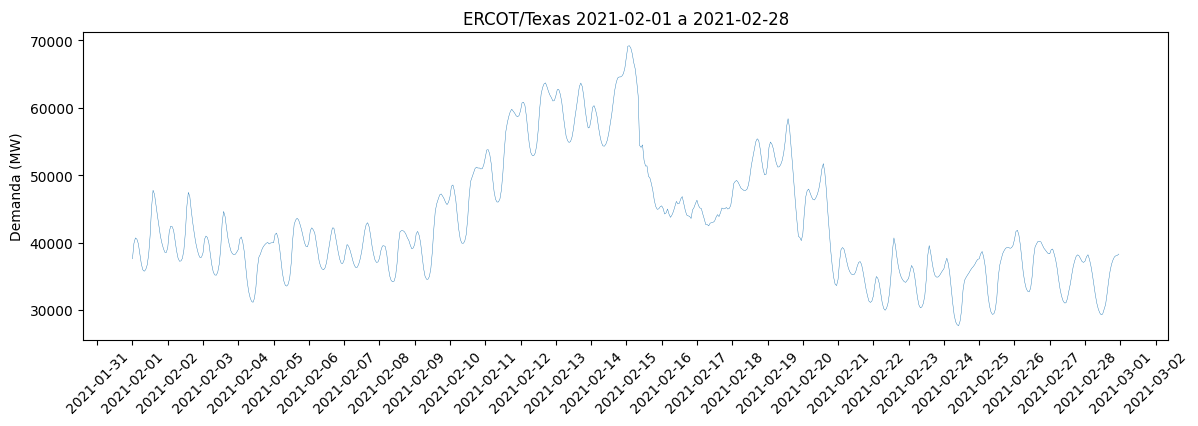

In [51]:

# Acercarse a las dos semanas con hora y todos los dias completos
sub = df.loc['2021-02-01':'2021-02-28', 'cleaned demand (MW)']
plt.figure(figsize=(14,4))
plt.plot(sub.index, sub.values, linewidth=0.3)
plt.ylabel('Demanda (MW)')
plt.title('ERCOT/Texas 2021-02-01 a 2021-02-28')

plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Punto 3 — La columna 'raw demand' vs 'cleaned demand': qué se imputó y dónde?
corr = df['raw demand (MW)'] - df['cleaned demand (MW)']
imputado = corr != 0

print(f'Horas con valor imputado/corregido: {imputado.sum()} '
      f'({imputado.mean()*100:.2f}% de la serie)')
print(f'Corrección mediana: {corr[imputado].abs().median():,.0f} MW') # Nota : casi cosmetica
print(f'Corrección máxima:  {corr.abs().max():,.0f} MW')

# Dónde se concentran las imputaciones?
conc = (imputado.groupby([imputado.index.year, imputado.index.month]).sum()
        .sort_values(ascending=False).head(5))
print('\nMeses con más horas imputadas:')
print(conc)

# La corrección más grande NO está en Uri
peor = corr.abs().idxmax()
print(f'\nMayor corrección en: {peor}')
print(df.loc[peor])


Horas con valor imputado/corregido: 549 (1.25% de la serie)
Corrección |mediana|: 254 MW  (casi cosmética)
Corrección |máxima|:  45,525 MW

Meses con más horas imputadas:
date_time  date_time
2023       10           73
           3            65
2022       2            29
2021       2            28
2024       11           25
dtype: int64

Mayor corrección en: 2024-08-25 22:00:00
raw demand (MW)        34066
cleaned demand (MW)    79591
Name: 2024-08-25 22:00:00, dtype: int64


### Hallazgos y **decisiones** sobre eventos atípicos y dato no confiable

**Tormenta Uri (feb-2021) — descripción → decisión.** El 9–10 de febrero de 2021 una
tormenta invernal extrema dispara la demanda de calefacción; del 14 al 19 de febrero la
serie **cae bruscamente**. Ese desplome **no es demanda real**: durante el apagón el dato
registrado es **carga servida**, limitada por la falta de generación es **demanda no
satisfecha**, un dato **corrupto para pronóstico**. y pues se toma una
decisión: **esta ventana no representa demanda real → la marcamos con una
variable dummy de evento y la mantenemos FUERA del conjunto de prueba**. (Despues de ver un poco mas, esto es un "quizas")

**COVID-19 (2020) — medido, no afirmado.** El confinamiento (15-mar a 30-abr 2020) dio
una demanda media de **37,788 MW** frente a **38,211 MW** en la misma ventana de 2021:
**−1.1 %**, dentro del ruido. En Texas (mezcla industrial/residencial distinta a otras
regiones) el confinamiento **apenas movió** la demanda. **Decisión:** no tratarlo como
choque estructural; basta con asegurar que 2020 caiga en **entrenamiento**.

**Horas imputadas — la columna que no debíamos ignorar.** El **1.25 % (549 horas)** de la
variable objetivo es **sintético**: lo imputó el algoritmo de limpieza de la fuente. No se
concentran en Uri sino en **octubre 2023 (73 h)** y **marzo 2023 (65 h)**. La corrección
mediana es **254 MW** (casi nadita), pero existe una de **45,525 MW** — un valor crudo
roto (raw ≈ 34,066 → limpio ≈ 79,591). esa corrección máxima **no es de Uri**, ocurre
el **2024-08-25** (pico de verano). **Decisión:** conservar una bandera `es_imputado` y, si
el conjunto de prueba cae sobre horas imputadas, reportarlo — evaluar un modelo contra
horas inventadas es calificarlo contra ficción.


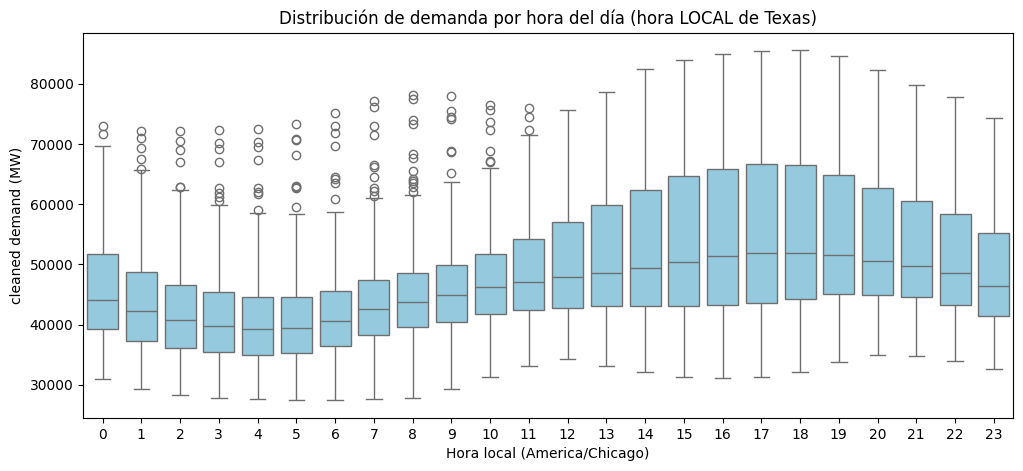

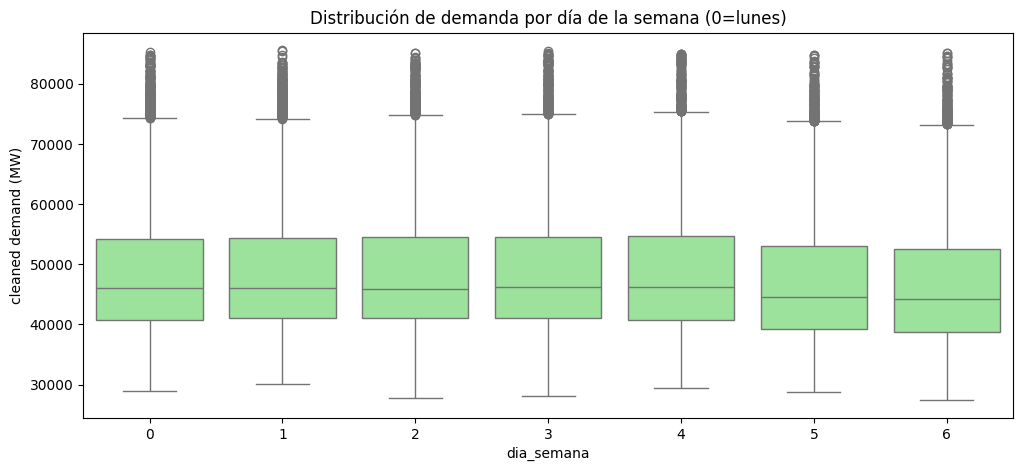

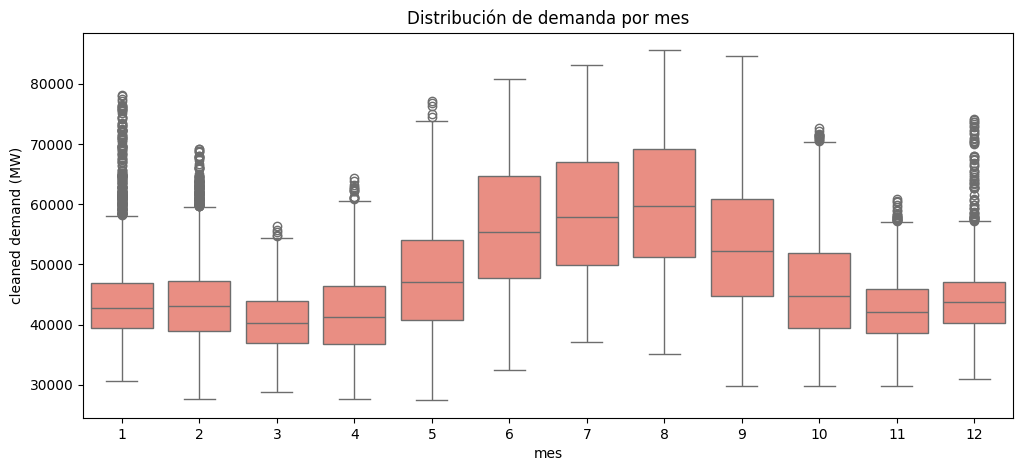

In [53]:
# Convertimos a hora local de Texas para que las etiquetas tengan sentido físico.
idx_local = df.index.tz_localize('UTC', ambiguous='NaT', nonexistent='NaT').tz_convert('America/Chicago')

df['hora_utc']   = df.index.hour            # como vienen los datos (UTC)
df['hora_local'] = idx_local.hour           # hora real de Texas
df['dia_semana'] = idx_local.dayofweek
df['mes']        = idx_local.month

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='hora_local', y='cleaned demand (MW)', color='skyblue')
plt.title('Distribución de demanda por hora del día (hora LOCAL de Texas)')
plt.xlabel('Hora local (America/Chicago)')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='dia_semana', y='cleaned demand (MW)', color='lightgreen')
plt.title('Distribución de demanda por día de la semana (0=lunes)')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='mes', y='cleaned demand (MW)', color='salmon')
plt.title('Distribución de demanda por mes')
plt.show()


## Ciclos observados (con números y en hora local)

- **Ciclo diario (en hora local de Texas):** pico alrededor de las **17 h (5 PM)** y valle
  hacia las **5 h (5 AM)**; en julio el pico es exactamente a las 17 h. La razón
  **pico/valle del perfil horario promedio es 1.37** (la demanda de la tarde es ~37 %
  mayor que la de la madrugada). *Nota: leído en UTC el pico aparece a las ~22 h por el
  desfase descrito arriba.*

- **Ciclo semanal:** los días **laborales** son ligeramente superiores a los **fines de
  semana** (~48,700 MW vs ~47,100 MW de media). El efecto existe pero es **modesto**
  comparado con los ciclos diario y anual.

- **Ciclo anual:** picos en **verano** (jun–ago), con **agosto** como mes de mayor
  demanda (mediana **~59,800 MW**) y **marzo** como el menor (mediana **~40,200 MW**).
  La brecha mediana verano–invierno es de **~19,600 MW**, una variación enorme.

**Decisiones de modelado derivadas:**
- Hay **estacionalidad múltiple** (diaria, semanal, anual). Para el modelo estadístico
  usar **SARIMA** con período estacional, o incorporar variables de calendario
  (hora, día de semana, mes) y términos de **Fourier** para las estacionalidades largas.
- Para la **LSTM**, la ventana de entrada debe cubrir al menos un ciclo diario completo
  (≥ 24 pasos) y conviene añadir features cíclicas (seno/coseno de hora y día).


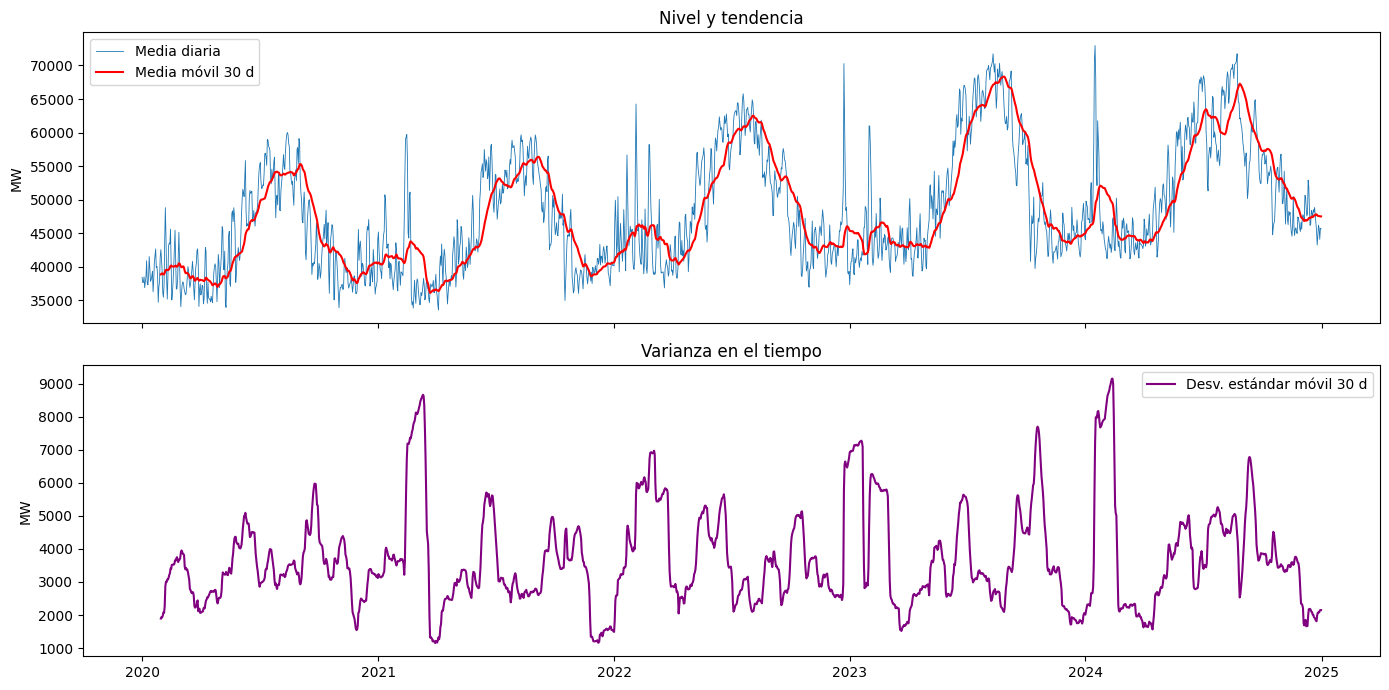

ADF sobre la serie horaria -> estadístico: -7.167 | p-valor: 0.0000
p < 0.05 => se rechaza H0 (estacionaria en sentido débil); aun así domina la fuerte estacionalidad anual.


In [54]:
# Punto 5 — Estacionariedad (supuesto central de ARIMA)
from statsmodels.tsa.stattools import adfuller

serie_dia = d.resample('D').mean()   # media diaria para ver tendencia/varianza con claridad

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax[0].plot(serie_dia.index, serie_dia.values, linewidth=0.6, label='Media diaria')
ax[0].plot(serie_dia.rolling(30).mean(), color='red', label='Media móvil 30 d')
ax[0].set_ylabel('MW'); ax[0].legend(); ax[0].set_title('Nivel y tendencia')
ax[1].plot(serie_dia.rolling(30).std(), color='purple', label='Desv. estándar móvil 30 d')
ax[1].set_ylabel('MW'); ax[1].legend(); ax[1].set_title('Varianza en el tiempo')
plt.tight_layout(); plt.show()

# Prueba ADF (H0: la serie tiene raíz unitaria = NO estacionaria)
adf = adfuller(d.dropna(), autolag='AIC')
print(f'ADF sobre la serie horaria -> estadístico: {adf[0]:.3f} | p-valor: {adf[1]:.4f}')
print('p < 0.05 => se rechaza H0 (estacionaria en sentido débil); '
      'aun así domina la fuerte estacionalidad anual.')


### Estacionariedad → decisión

La media móvil muestra una **fuerte oscilación estacional anual** (verano alto, invierno
bajo) y la desviación estándar móvil **no es constante**: la varianza es mayor en los meses
de verano (**heterocedasticidad estacional**). La serie horaria pasa la prueba ADF
(p < 0.05) por la masa de observaciones, pero eso **no elimina la estacionalidad**.

**Decisiones de modelado derivadas:**
- **ARIMA:** la serie **no es estacionaria en media estacional** → aplicar **diferenciación
  estacional** (p. ej. SARIMA con período diario/anual) y considerar transformación
  **log/Box-Cox** para la varianza creciente en verano. Verificar residuos con ACF/PACF.
- **LSTM:** no exige estacionariedad, pero el escalado y las features de calendario ayudan
  a que aprenda los ciclos sin tener que reconstruir la tendencia estacional desde cero.


## Resumen

| Hallazgo del EDA | Decisión de modelado |
|---|---|
| Timestamps en **UTC** (pico real 17 h local) | Fijar una zona horaria única; convertir antes de unir clima/temperatura para evitar desfase de 5–6 h |
| Distribución **sesgo derecho** (skew 0.92, curtosis 0.39) | log/Box-Cox para ARIMA; escalado (solo con train) para LSTM |
| **Estacionalidad múltiple** (diaria 1.37×, semanal leve, anual ~19,600 MW) | SARIMA / términos de Fourier; features de calendario y cíclicas; ventana LSTM ≥ 24 h |
| Serie **no estacionaria** en media/varianza estacional | Diferenciación estacional + transformación de varianza para ARIMA |
| **COVID** = −1.1 % (ruido) | No es choque estructural; 2020 va en train |
| **1.25 % (549 h) imputado**, máx 45,525 MW (ago-2024) | Bandera `es_imputado`; reportar si el test cae sobre horas imputadas |
| **Tarea: pronóstico a 24 h** | Define horizonte de evaluación (MAE/RMSE/MAPE a 24 h) y diseño walk-forward |
